In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Import and Inspection

In [ ]:
link = ''
df = pd.read_csv(link +'holdings_anonymized.csv')
print(df.shape)
print(df.columns)
df.head()

/var/folders/s9/8lwyvym11jq10x6wm3r2wmgm0000gn/T/ipykernel_15449/13547612.py:2: DtypeWarning: Columns (10,18,20,21,22,24,25,45,47,49,53,55,57,59,61,63,65,67,72,76,80,82,84,86,88,90,95,97,101,103,105,107,115,131,133,135,143,151,161,167,177,179,199,201,203,215,221,223,225,227,229,231,232,234,236,238,240,242,244,246,248,250,252,254,256,258,260,262,264,266,268,270,272,288,290,292,298,300,304,306,308,310,312,314,324,326,328,330,332,334,336,338,340,342,344,346,348,350,352,354,358,360,362,364,366,368,370,372,374,376,378,380,382,384,386,388,390,392,394,396,398,400,402,404,406,408,410,412,414,416,418,420,422,424,426,428,430,432,434,436,438,440,442,444,446,448,450,454,456,462,464,466,470,472,484,490,496,500,502,504,506,508,510,512,514,516,518,520,522,524,526,528,532,534,536,538,540,542,545,550,554,558,561,563,568,570,572,573,576,578,581,584,586,589,606,631,638,640,644,662,664,666,668,670,672,678,680,694,696,698,702,704,712,714,716,722,724,728,730,732,734,740,746,750,756,768,769,772,774,776,778,7

(58160, 837)
Index(['Investment Manager Allocator ID', 'Fund Allocator ID', 'Source Asset',
       'Source Asset ID', 'Is Instrument', 'Instrument Name', 'Instrument ID',
       'As At Date', 'Deal Status', 'Asset Status',
       ...
       'Latest/Exit EBITDA Multiple', 'Latest/Exit EBITDA Multiple Unit',
       'Latest/Exit Pro Forma EBITDA Multiple',
       'Latest/Exit Pro Forma EBITDA Multiple Unit',
       'Latest/Exit Adjusted EBITDA Multiple',
       'Latest/Exit Adjusted EBITDA Multiple Unit',
       'Latest/Exit Net Debt Multiple', 'Latest/Exit Net Debt Multiple Unit',
       'Latest/Exit Debt Multiple', 'Latest/Exit Debt Multiple Unit'],
      dtype='object', length=837)


,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit
0,Afc0dbf,Aa967c0,"8000 Tartak Street Owner LLC (""Embassy Suites"")",Add4554,NaN,NaN,NaN,31-Mar-26,Current,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afc0dbf,Aa967c0,Non-Investment Assets - Cash,A047cfd,NaN,NaN,NaN,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afc0dbf,Aa967c0,Non-Investment Assets - Other Assets,A21dc07,NaN,NaN,NaN,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afc0dbf,Aa967c0,Non-Investment Liabilities - Other Liabilities,A4f93a9,NaN,NaN,NaN,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A664a6a,Ad52755,Non-Investment Assets - Cash,489269,NaN,NaN,NaN,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df['As At Date'].unique()

array(['31-Mar-26', '31-Dec-25', '30-Sep-25', '30-Jun-25', '31-Mar-25',
       '31-Dec-24'], dtype=object)

The fund holdings data is from 2024-2026 quarterly.

In [28]:
missing = pd.DataFrame({'missing_cnt': df.isnull().sum(), 
                       'missing_pnt': df.isnull().mean()*100}).sort_values('missing_pnt', ascending=False)
missing[missing['missing_cnt'] > 0]

,missing_cnt,missing_pnt
Projected QTD EBIT Unit,58160,100.000000
Maturity Date Unit,58160,100.000000
Projected Adjusted LTM EBITA YoY % Change Unit,58160,100.000000
Frequency Unit,58160,100.000000
Projected Adjusted LTM EBITA 3 Year CAGR,58160,100.000000
...,...,...
Sector,129,0.221802
Sector Level 1,129,0.221802
Geographic Focus,31,0.053301
Geography Level 1,31,0.053301


Only 7 attributes are 100% complete. Up to 249 attributes are 100% missing. We will drop the 100% missing attributes as they provide no useful information.

In [ ]:
df_clean = df.dropna(axis=1, how='all').copy()
df.shape[1] - df_clean.shape[1]

249

In [30]:
df[df.duplicated()]

,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit


Check the deal status, no typo of the status name or inconsistent name.

In [32]:
df_clean['Deal Status'].value_counts(dropna=False)

Deal Status
Current                                     28713
Fully Exited                                10910
NaN                                          6639
Partially Exited                             5757
Written Down                                 3105
Written Off                                  2526
Partially Exited, Remainder Written Down      510
Name: count, dtype: int64

In [33]:
df_clean['As At Date'] = pd.to_datetime(df_clean['As At Date'], dayfirst=True)
df_clean['Initial Investment Date'] = pd.to_datetime(df_clean['Initial Investment Date'], errors='coerce')

/var/folders/s9/8lwyvym11jq10x6wm3r2wmgm0000gn/T/ipykernel_15449/1472401861.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['As At Date'] = pd.to_datetime(df_clean['As At Date'], dayfirst=True)


In [34]:
df.columns.to_frame(name = 'df_attributes', index=False).to_csv('holdings_attributes.csv', index=False)

In [ ]:
# separate unit cols from value cols
unit_cols = [c for c in df_clean.columns if c.endswith('Unit')]
value_cols = [c for c in df_clean.columns if c not in unit_cols]
df_values = df_clean[value_cols].copy()

fill_rates = df_values.notna().mean().sort_values()
empty_cols = (fill_rates == 0).sum()
full_cols = (fill_rates == 1).sum()
partial_cols = ((fill_rates > 0) & (fill_rates < 1)).sum()
print(f'\n--- Completeness SUMMARY ---')
print(f'Completely empty columns : {empty_cols}')
print(f'Completely full columns  : {full_cols}')
print(f'Partially filled columns : {partial_cols}')
print(f'\nBottom 15 (worst gaps):')
print(fill_rates.head(15).apply(lambda x: f'{x:%}').to_string())



--- Completeness SUMMARY ---
Completely empty columns : 0
Completely full columns  : 7
Partially filled columns : 322

Bottom 15 (worst gaps):
Projected LTM EBIT YoY % Change              0.001719%
Non Current Liabilities                      0.001719%
YTD EBIT Margin                              0.001719%
Projected Adjusted QTD EBITDA Margin         0.001719%
Projected LTM EBITA 3 Year CAGR              0.001719%
Non Current Assets                           0.001719%
Proceeds from Disposal                       0.001719%
Projected Adjusted LTM EBITDA 3 Year CAGR    0.001719%
Current Liabilities                          0.001719%
IPO Date                                     0.001719%
Projected YTD Gross Profit                   0.001719%
LTM Net Cash Flow From Operations            0.001719%
YTD EBIT                                     0.001719%
QTD EBIT                                     0.001719%
Current Assets                               0.001719%


In [ ]:
key_fields = {
    'Identity':     ['Deal Status', 'Asset Status', 'Type of Investment', 'Instrument Type'],
    'Classification': ['Sector', 'Sector Level 1', 'Geographic Focus', 'Geography Level 1',
                       'GP Reported Sector', 'GP Reported Geography'],
    'Financials':   ['Current Cost', 'Realized Proceeds', 'Unrealized Value', 'Total Value',
                     'Capital Invested', 'Realized Gain/Loss', 'Unrealized Gain/Loss'],
    'Returns':      ['DPI', 'Gross TVPI', 'Gross IRR', 'Net TVPI', 'Net IRR', 'RVPI'],
    'Dates':        ['Initial Investment Date', 'Exit Date', 'As At Date'],
    'Ownership':    ['Primary Ownership Percentage', 'Diluted Ownership Percentage'],
}

print('\n--- KEY FIELDS BY CATEGORY---')
for category, fields in key_fields.items():
    print(f'\n{category}:')
    for f in fields:
        if f in df_values.columns:
            rate = df_values[f].notna().mean()
            print(f'  {f:<45} {rate:.1%}')


--- KEY FIELDS BY CATEGORY---

Identity:
  Deal Status                                   88.6%
  Asset Status                                  99.2%
  Type of Investment                            100.0%
  Instrument Type                               57.1%

Classification:
  Sector                                        99.8%
  Sector Level 1                                99.8%
  Geographic Focus                              99.9%
  Geography Level 1                             99.9%
  GP Reported Sector                            25.7%
  GP Reported Geography                         27.2%

Financials:
  Current Cost                                  86.1%
  Realized Proceeds                             80.9%
  Unrealized Value                              98.9%
  Total Value                                   81.1%
  Capital Invested                              80.1%
  Realized Gain/Loss                            78.1%
  Unrealized Gain/Loss                          86.1%

Returns:

In [81]:
print('--- Deal Status Completeness---')
ds =df_values['Deal Status'].value_counts(dropna=False)
total = len(df_values)
for val, count in ds.items():
    label = str(val) if pd.notna(val) else 'MISSING'
    print(f"  {label:<50} {count:>6,}  ({count/total:.1%})")


--- Deal Status Completeness---
  Current                                            28,713  (49.4%)
  Fully Exited                                       10,910  (18.8%)
  MISSING                                             6,639  (11.4%)
  Partially Exited                                    5,757  (9.9%)
  Written Down                                        3,105  (5.3%)
  Written Off                                         2,526  (4.3%)
  Partially Exited, Remainder Written Down              510  (0.9%)


In [98]:
mandatory = ['Deal Status', 'Current Cost', 'Unrealized Value', 
             'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value']
fund_quality = df_values.groupby('Fund Allocator ID')[mandatory].apply(
    lambda x: x.notna().mean().mean()
).sort_values(ascending=False)

print(f'Scored on: {mandatory}')
for fund, score in fund_quality.head(10).items():
    print(f'  Fund {fund}:  {score:.1%} avg fill rate')

print('\nBottom 10 (least complete):')
for fund, score in fund_quality.tail(10).items():
    print(f'  {fund}:  {score:.1%}')

Scored on: ['Deal Status', 'Current Cost', 'Unrealized Value', 'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value']
  Fund A18cb9a:  100.0% avg fill rate
  Fund A06c397:  100.0% avg fill rate
  Fund A6c91e2:  100.0% avg fill rate
  Fund A722c06:  100.0% avg fill rate
  Fund A41676f:  100.0% avg fill rate
  Fund A3bf5bd:  100.0% avg fill rate
  Fund 94148b:  99.8% avg fill rate
  Fund A8b56b9:  99.4% avg fill rate
  Fund A5a0710:  99.2% avg fill rate
  Fund Abb96b2:  99.1% avg fill rate

Bottom 10 (least complete):
  Aa7f6d4:  50.0%
  Ad52755:  50.0%
  Ae4c498:  49.4%
  Adf56a5:  47.6%
  A2989df:  46.4%
  A103ce5:  46.4%
  A7199bc:  46.4%
  A80d406:  44.4%
  Ae7bb35:  42.4%
  Ab3ea87:  37.5%


In [99]:
df_clean['Fund Allocator ID'].value_counts()

Fund Allocator ID
A5a0710    1327
A16c87d     882
A8b56b9     682
A14ab79     659
Ac58438     648
           ... 
A947e8c       4
Aa7f6d4       4
A615cff       3
Af5c876       3
A221849       3
Name: count, Length: 385, dtype: int64


--- ENTITY RESOLUTION SCOPE ---
Unique companies = 8,706
Total non-null rows = 58,160
Avg appearances per company = 6.7
Companies held by >1 fund: 1,142  ← entity resolution targets

✓ Chart saved: fill_rate_chart.png


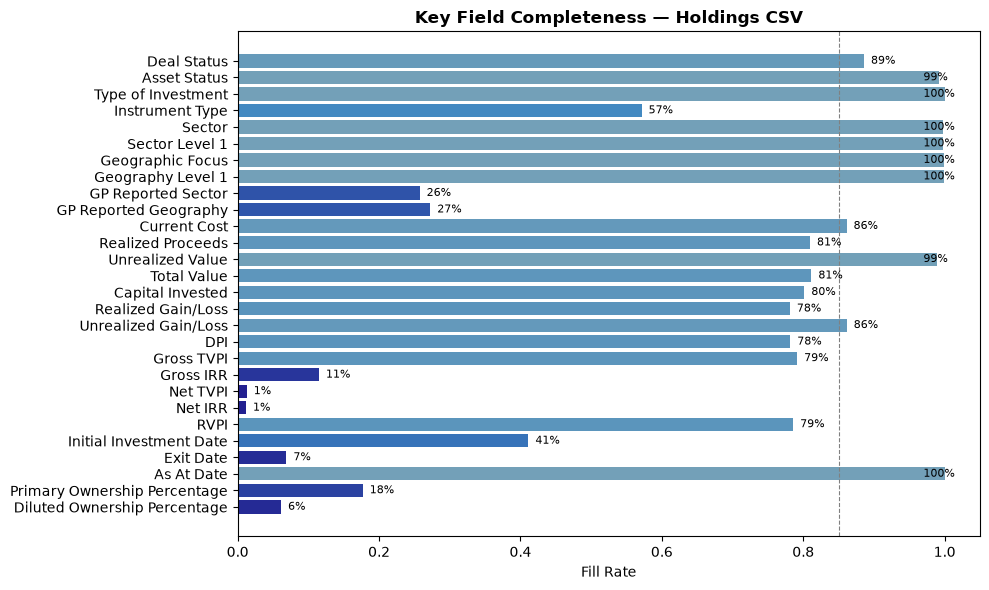

In [108]:
import matplotlib.colors as mcolors

company_col = 'Source Asset'
unique_companies = df_values[company_col].nunique()
total_rows       = df_values[company_col].notna().sum()
print(f'\n--- ENTITY RESOLUTION SCOPE ---')
print(f'Unique companies = {unique_companies:,}')
print(f'Total non-null rows = {total_rows:,}')
print(f'Avg appearances per company = {total_rows/unique_companies:.1f}')

# companies appearing in >1 fund (cross-fund holdings — the interesting ones)
company_fund_counts = df_values.groupby(company_col)['Fund Allocator ID'].nunique()
multi_fund = company_fund_counts[company_fund_counts > 1]
print(f"Companies held by >1 fund: {len(multi_fund):,}  ← entity resolution targets")


# heatmap for key fields
all_key = [f for cat in key_fields.values() for f in cat if f in df_values.columns]
fill_key = df_values[all_key].notna().mean()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#221e8f", "#3b85c2", "#73a0b8"]
cmap = mcolors.LinearSegmentedColormap.from_list('rg', colors)
bars = ax.barh(fill_key.index[::-1], fill_key.values[::-1],
               color=[cmap(v) for v in fill_key.values[::-1]])
ax.axvline(0.85, color='gray', linestyle='--', linewidth=0.8, label='85% threshold')
ax.set_xlabel('Fill Rate')
ax.set_title('Key Field Completeness — Holdings CSV', fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, fill_key.values[::-1]):
    ax.text(min(val + 0.01, 0.97), bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fill_rate_chart.png', dpi=150, bbox_inches='tight')
print("\n✓ Chart saved: fill_rate_chart.png")

# TABLE for ops review
flag_cols = ['Fund Allocator ID', 'Source Asset', 'As At Date',
             'Deal Status', 'Current Cost', 'Realized Proceeds', 'Unrealized Value']
flag_cols = [c for c in flag_cols if c in df_values.columns]
flagged = df_values[df_values[flag_cols[3:]].isnull().any(axis=1)][flag_cols]
flagged.to_csv('flagged_missing_fields.csv', index=False)

